# Elliptic Fourier fitting 比較ノート

このノートブックでは、実数値の周期関数 \(f(x)\) をサンプルして、

- **通常の Fourier fitting**（\(k=0\)）
- **楕円版 Fourier fitting**（\(k\) を最適化）

を同じグラフ上で比較します。

使う楕円版基底は

\[
e^{ij	heta_k(x)}, \qquad
	heta_k(x)=\operatorname{am}\!\left(
rac{2K(k)}{\pi}x,\;k
ight)
\]

です。  
ここで \(K(k)\) は完全楕円積分、\(\operatorname{am}\) は Jacobi 振幅関数です。

## 使い方
1. 下の **ユーザー設定セル** で `f(x)` を定義
2. `N`, `sample_count`, `k_bounds` などを設定
3. その下のセルを順番に実行

## 注意
- `f(x)` は **\(2\pi\)-周期関数** を想定しています。
- 可視化しやすいように、ここでは **実数値関数** を前提にしています。
- `k=0` のとき、楕円版は厳密に通常の Fourier fitting に一致します。


In [ ]:
# Colab で未インストールなら実行
# 通常は SciPy / NumPy / matplotlib は入っています。
# 必要なときだけコメント解除してください。
# !pip -q install scipy


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.special import ellipj, ellipk
from scipy.optimize import minimize_scalar


def theta_warp(x: np.ndarray, k: float) -> np.ndarray:
    """
    theta_k(x) = am((2K(k)/pi) x, k)
    これにより x の周期 2π を保ったまま、位相だけを楕円的に歪める。
    """
    x = np.asarray(x, dtype=float)

    if not (0.0 <= k < 1.0):
        raise ValueError("k must satisfy 0 <= k < 1.")

    if abs(k) < 1e-15:
        return x.copy()

    alpha = 2.0 * ellipk(k * k) / np.pi
    u = alpha * x
    sn, cn, dn, ph = ellipj(u, k * k)  # SciPy では第2引数は m = k^2
    return ph


def design_fourier(x: np.ndarray, N: int):
    """
    A[m, r] = exp(i * j_r * x_m),  j_r = -N, ..., N
    """
    j = np.arange(-N, N + 1, dtype=int)
    A = np.exp(1j * np.outer(x, j))
    return A, j


def design_elliptic(x: np.ndarray, N: int, k: float):
    """
    A[m, r] = exp(i * j_r * theta_k(x_m))
    """
    theta = theta_warp(x, k)
    j = np.arange(-N, N + 1, dtype=int)
    A = np.exp(1j * np.outer(theta, j))
    return A, j, theta


def solve_complex_ridge(A: np.ndarray, y: np.ndarray, ridge: float = 1e-10):
    """
    min ||A c - y||^2 + ridge ||c||^2
    """
    AH = A.conj().T
    n = A.shape[1]
    return np.linalg.solve(AH @ A + ridge * np.eye(n, dtype=A.dtype), AH @ y)


def fit_fourier(x: np.ndarray, y: np.ndarray, N: int, ridge: float = 1e-10):
    A, j = design_fourier(x, N)
    coeffs = solve_complex_ridge(A, y, ridge=ridge)
    y_hat = np.real(A @ coeffs)
    rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
    return {
        "name": "ordinary Fourier (k=0)",
        "N": N,
        "k": 0.0,
        "j": j,
        "coeffs": coeffs,
        "A": A,
        "y_hat": y_hat,
        "rmse": rmse,
        "theta": x,
    }


def fit_elliptic_fixed_k(x: np.ndarray, y: np.ndarray, N: int, k: float, ridge: float = 1e-10):
    A, j, theta = design_elliptic(x, N, k)
    coeffs = solve_complex_ridge(A, y, ridge=ridge)
    y_hat = np.real(A @ coeffs)
    rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
    return {
        "name": f"elliptic Fourier (k={k:.6f})",
        "N": N,
        "k": float(k),
        "j": j,
        "coeffs": coeffs,
        "A": A,
        "y_hat": y_hat,
        "rmse": rmse,
        "theta": theta,
    }


def fit_elliptic_optimized(
    x: np.ndarray,
    y: np.ndarray,
    N: int,
    k_bounds=(0.0, 0.98),
    k_grid_size: int = 41,
    refine: bool = True,
    ridge: float = 1e-10,
):
    """
    1. 粗いグリッド探索
    2. 必要なら bounded optimization で微調整
    """
    k_min, k_max = k_bounds
    if not (0.0 <= k_min < k_max < 1.0):
        raise ValueError("Require 0 <= k_min < k_max < 1.")

    k_grid = np.linspace(k_min, k_max, k_grid_size)
    fits = [fit_elliptic_fixed_k(x, y, N=N, k=float(k), ridge=ridge) for k in k_grid]
    best = min(fits, key=lambda d: d["rmse"])
    best_k = best["k"]

    if refine:
        best_idx = int(np.argmin([f["rmse"] for f in fits]))
        left_idx = max(best_idx - 1, 0)
        right_idx = min(best_idx + 1, len(k_grid) - 1)

        a = float(k_grid[left_idx])
        b = float(k_grid[right_idx])

        if a == b or best_idx in (0, len(k_grid) - 1):
            a, b = k_min, k_max

        def objective(k):
            return fit_elliptic_fixed_k(x, y, N=N, k=float(k), ridge=ridge)["rmse"]

        opt = minimize_scalar(objective, bounds=(a, b), method="bounded")
        if opt.success:
            refined_fit = fit_elliptic_fixed_k(x, y, N=N, k=float(opt.x), ridge=ridge)
            if refined_fit["rmse"] <= best["rmse"]:
                best = refined_fit

    return best


def compare_models(
    f,
    N: int = 9,
    sample_count: int = 512,
    k_bounds=(0.0, 0.98),
    k_grid_size: int = 41,
    refine: bool = True,
    ridge: float = 1e-10,
    dense_plot_count: int = 2000,
):
    """
    関数 f をサンプルし、
    - 通常 Fourier
    - k 最適化した楕円 Fourier
    を比較して返す。
    """
    x = np.linspace(0.0, 2.0 * np.pi, sample_count, endpoint=False)
    y = np.asarray(f(x), dtype=float)

    ordinary_fit = fit_fourier(x, y, N=N, ridge=ridge)
    elliptic_fit = fit_elliptic_optimized(
        x, y, N=N, k_bounds=k_bounds, k_grid_size=k_grid_size, refine=refine, ridge=ridge
    )

    # 滑らかな表示用
    x_dense = np.linspace(0.0, 2.0 * np.pi, dense_plot_count, endpoint=False)
    y_dense = np.asarray(f(x_dense), dtype=float)

    A_dense_fourier, _ = design_fourier(x_dense, N)
    y_dense_fourier = np.real(A_dense_fourier @ ordinary_fit["coeffs"])

    A_dense_elliptic, _, theta_dense = design_elliptic(x_dense, N, elliptic_fit["k"])
    y_dense_elliptic = np.real(A_dense_elliptic @ elliptic_fit["coeffs"])

    return {
        "x": x,
        "y": y,
        "x_dense": x_dense,
        "y_dense": y_dense,
        "ordinary_fit": ordinary_fit,
        "elliptic_fit": elliptic_fit,
        "y_dense_fourier": y_dense_fourier,
        "y_dense_elliptic": y_dense_elliptic,
        "theta_dense": theta_dense,
    }


def plot_comparison(result, title: str = "Fourier vs elliptic Fourier"):
    x = result["x"]
    y = result["y"]
    x_dense = result["x_dense"]
    y_dense = result["y_dense"]
    y_dense_fourier = result["y_dense_fourier"]
    y_dense_elliptic = result["y_dense_elliptic"]
    ordinary_fit = result["ordinary_fit"]
    elliptic_fit = result["elliptic_fit"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

    # --- 上段: 近似比較 ---
    ax = axes[0]
    ax.plot(x_dense, y_dense, label="target function", linewidth=2)
    ax.plot(x_dense, y_dense_fourier, label=f"ordinary Fourier (N={ordinary_fit['N']})")
    ax.plot(x_dense, y_dense_elliptic,
            label=f"elliptic Fourier (N={elliptic_fit['N']}, k={elliptic_fit['k']:.4f})")

    ax.scatter(x, y, s=12, alpha=0.5, label="sample points")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    ax.legend()

    text = (
        f"RMSE ordinary = {ordinary_fit['rmse']:.6e}\n"
        f"RMSE elliptic = {elliptic_fit['rmse']:.6e}\n"
        f"best k = {elliptic_fit['k']:.6f}\n"
        f"improvement ratio = {elliptic_fit['rmse'] / ordinary_fit['rmse']:.6f}"
    )
    ax.text(
        0.02, 0.02, text, transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
        verticalalignment="bottom"
    )

    # --- 下段: 位相歪み theta_k(x) の形 ---
    ax2 = axes[1]
    ax2.plot(x_dense, x_dense, label=r"$\theta(x)=x$  (ordinary)")
    ax2.plot(x_dense, result["theta_dense"], label=rf"$\theta_k(x)$  (k={elliptic_fit['k']:.4f})")
    ax2.set_title("phase warp")
    ax2.set_xlabel("x")
    ax2.set_ylabel(r"$\theta$")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    fig.tight_layout()
    plt.show()


def print_summary(result):
    ordinary_fit = result["ordinary_fit"]
    elliptic_fit = result["elliptic_fit"]

    print("=== Summary ===")
    print(f"N                 : {ordinary_fit['N']}")
    print(f"RMSE ordinary     : {ordinary_fit['rmse']:.10e}")
    print(f"RMSE elliptic     : {elliptic_fit['rmse']:.10e}")
    print(f"best k            : {elliptic_fit['k']:.10f}")
    print(f"improvement ratio : {elliptic_fit['rmse'] / ordinary_fit['rmse']:.10f}")


In [36]:

# =========================
# ユーザー設定
# =========================

# ここを好きな 2π-周期関数に変えてください
# 例1: 矩形波
#f = lambda x: np.where(np.sin(x) >= 0.0, 1.0, -1.0)

# 例2: のこぎり波
# f = lambda x: ((x + np.pi) % (2*np.pi) - np.pi) / np.pi

# 例3: 三角波
#f = lambda x: (2.0 / np.pi) * np.arcsin(np.sin(x))

# 例4: 尖った滑らかな周期波
#vf = lambda x: np.exp(3.0 * np.cos(x)) / np.exp(3.0)

# 例5: 自由に定義
#f = lambda x: np.where(np.sin(x*x) >= 0, 1.0, -1.0)
#f = lambda x: np.sin(x*x)
#f = lambda x: np.floor(x)

# 打ち切り次数（基底数は 2N+1）
N = 9

# サンプル点数（少なくとも 2N+1 は必要）
sample_count = 512

# k の探索範囲
k_bounds = (0.0, 0.98)

# 粗い探索の分割数
k_grid_size = 41

# 粗探索のあとに微調整するか
refine = True

# リッジ正則化（悪条件化対策）
ridge = 1e-10

# 表示用の細かい点数
dense_plot_count = 2000


=== Summary ===
N                 : 9
RMSE ordinary     : 4.8612383523e-01
RMSE elliptic     : 3.7777083976e-01
best k            : 0.9800000000
improvement ratio : 0.7771082436


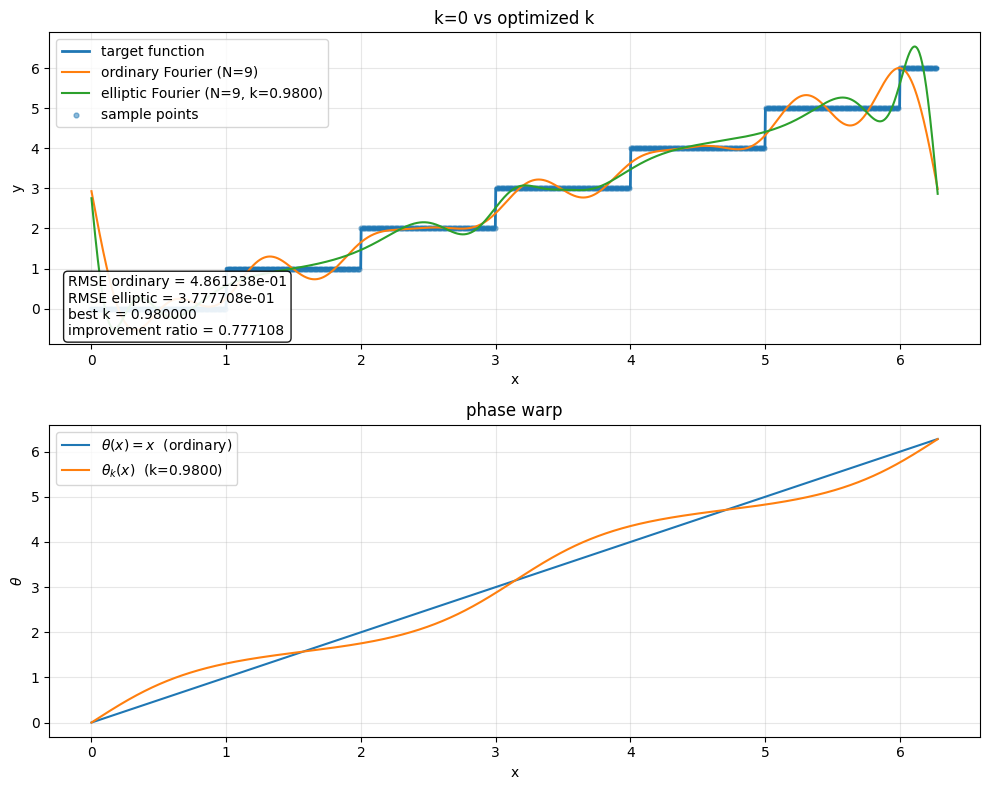

In [37]:

result = compare_models(
    f=f,
    N=N,
    sample_count=sample_count,
    k_bounds=k_bounds,
    k_grid_size=k_grid_size,
    refine=refine,
    ridge=ridge,
    dense_plot_count=dense_plot_count,
)

print_summary(result)
plot_comparison(result, title="k=0 vs optimized k")


In [4]:

# 推定された複素係数を見たいとき
print("ordinary Fourier coefficients:")
print(result["ordinary_fit"]["coeffs"])
print()
print("elliptic Fourier coefficients:")
print(result["elliptic_fit"]["coeffs"])


ordinary Fourier coefficients:
[4.99009756e-17+7.06636103e-02j 3.90625000e-03+3.99937623e-17j
 1.38588152e-18+9.08897485e-02j 3.90625000e-03+4.37860182e-17j
 1.15872568e-16+1.27284005e-01j 3.90625000e-03+6.32838414e-17j
 9.37453364e-17+2.12182622e-01j 3.90625000e-03+7.33414081e-18j
 6.81111796e-17+6.36611783e-01j 3.90625000e-03+2.56646520e-32j
 1.61553113e-16-6.36611783e-01j 3.90625000e-03-8.83202098e-17j
 1.25402499e-16-2.12182622e-01j 3.90625000e-03-4.14432060e-17j
 1.15872568e-16-1.27284005e-01j 3.90625000e-03-1.90023100e-17j
 2.77612748e-17-9.08897485e-02j 3.90625000e-03-6.47161796e-17j
 6.38387292e-17-7.06636103e-02j]

elliptic Fourier coefficients:
[-2.55858375e-16+5.67732025e-02j  5.81540849e-03+1.74939032e-16j
 -3.09264090e-16+9.27823349e-02j  7.76175314e-03+2.16261291e-16j
 -3.87223677e-16+1.26517542e-01j  7.43160488e-03+1.13443607e-16j
 -2.97582096e-16+2.12407864e-01j  7.55063520e-03-3.15909519e-17j
 -1.93420559e-16+6.36412788e-01j  7.48419283e-03-1.19601663e-17j
 -3.23558383

## 補足

この notebook で比較している 2 つのモデルは

### 1. 通常の Fourier fitting
\[
y(x)\approx \sum_{j=-N}^{N} c_j e^{ijx}
\]

### 2. 楕円版 Fourier fitting
\[
y(x)\approx \sum_{j=-N}^{N} c_j e^{ij\theta_k(x)},
\qquad
\theta_k(x)=\operatorname{am}\!\left(\frac{2K(k)}{\pi}x,\;k\right)
\]

です。

- \(k=0\) なら \(\theta_k(x)=x\) なので、楕円版は通常版に一致します。
- 尖った波や急変を持つ波では、最適化した \(k\) によって近似が改善することがあります。
- 逆に、通常 Fourier がすでに自然な波では、最適な \(k\) が 0 に近づくことがあります。
